# Training the visual search model, start to finish

This notebook builds, explains, and trains the model that predicts
**where the eyes go first** in visual search — fitted to 114,232
first eye movements from 333 people across 11 published experiments.

**Scope:** the first saccade of each trial, launched from the screen
center. Later saccades need extra machinery (inhibition of return,
moving vantage points) and are out of scope.

**In and out:** a picture of the display, the goal (color + shape),
and the previous trials go in; a probability for every item comes
out. One predicted saccade is one random draw.

**Before running** (needs the public data from https://osf.io/q27ph/):

    python pool_data.py --data_dir ".../Data Files" --out_dir dataset
    python build_contexts.py

Needs numpy, pandas, matplotlib, torch. Training: ~10 minutes.


In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from front_end import render, shape_for, item_positions, IMG
from build_contexts import (shape_match_map, sensory_salience_map,
                            template_match_map, paint_history_footprints)


## 1. Model structure

The fitted model is item-based. For each candidate item $i$, it combines three item-level quantities into one priority value:

$$ F_i = \underbrace{w_S\, S_i}_{\text{sensory evidence}} + \underbrace{w_G\, G_i}_{\text{template evidence}} + \underbrace{w_H\, H_i}_{\text{target history}} $$

- $S_i$: goal-independent bottom-up color salience for item $i$ (§3).
- $G_i$: unified green-circle template evidence for item $i$ (§4), combining signed color match and signed shape match.
- $H_i$: target-history trace for item slot $i$ (§5).
- Units: $S_i$ and $H_i$ are in $[0,1]$; $G_i$ is in $[-1,1]$.

The 2-D maps shown in the notebook are visualization/construction aids. They show where item evidence lives on the display, but the fitted model consumes the item table $A[\text{context}, i, \text{field}]$ directly.

**Choice (softmax).** Exponentiate the valid item priorities and divide by their sum. Higher priority means higher probability, but never all of it — that softness is what captures the variability in real eye movements:

$$ \Pr(\text{first saccade} = i) =
\frac{e^{F_i}}{\sum_j e^{F_j}}. $$

**Between trials** target history is a LEAKY ACCUMULATOR: every location fades by $(1-\eta_H)$, and the location the target actually occupied gets a boost of $\eta_H$. So $\eta_H$ is the WEIGHT ON THE MOST RECENT TRIAL: large $\eta_H$ — the last trial or two dominate; small $\eta_H$ — many past trials average together:

$$ H \leftarrow (1-\eta_H)\, H + \eta_H\, e_H. $$

**Four learned parameters:** $w_S, w_G, w_H, \eta_H$.

Two honest notes. (1) A two-color display cannot separate "enhance the target color" from "suppress the distractor color" — only the NET effect is identified — so the template map carries signed color evidence. (2) There is no attention window: with every first-saccade item equally far from fixation, a window would scale all six priorities by the same number, which the gains absorb.


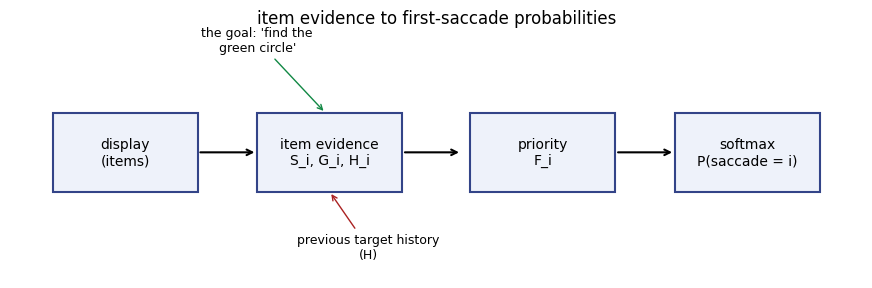

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.05, "display\n(items)"),
         (0.29, "item evidence\nS_i, G_i, H_i"),
         (0.54, "priority\nF_i"),
         (0.78, "softmax\nP(saccade = i)")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.17, 0.32, fc="#eef2fa", ec="#334488", lw=1.5))
    ax.text(x + 0.085, 0.51, label, ha="center", va="center", fontsize=10)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.24, 0.51), xytext=(x + 0.17, 0.51), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'find the\ngreen circle'", xy=(0.37, 0.67), xytext=(0.29, 0.92), ha="center", fontsize=9, arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previous target history\n(H)", xy=(0.375, 0.35), xytext=(0.42, 0.08), ha="center", fontsize=9, arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.set_xlim(0, 1.0); ax.set_ylim(0, 1); ax.axis("off")
plt.title("item evidence to first-saccade probabilities")
plt.show()


## 2. The displays: one example per study

Eleven experiments, pooled. Each subject searched one fixed shape
all session, so displays are reconstructed canonically: a CIRCLE
target among mixed other shapes, green items, one red color
singleton. The target never pops out — it is found by shape; the
singleton does pop out. (Each study's own color pair is shown here
for flavor; Hamblin-Frohman ships no color labels, so it falls
back to green/red.)


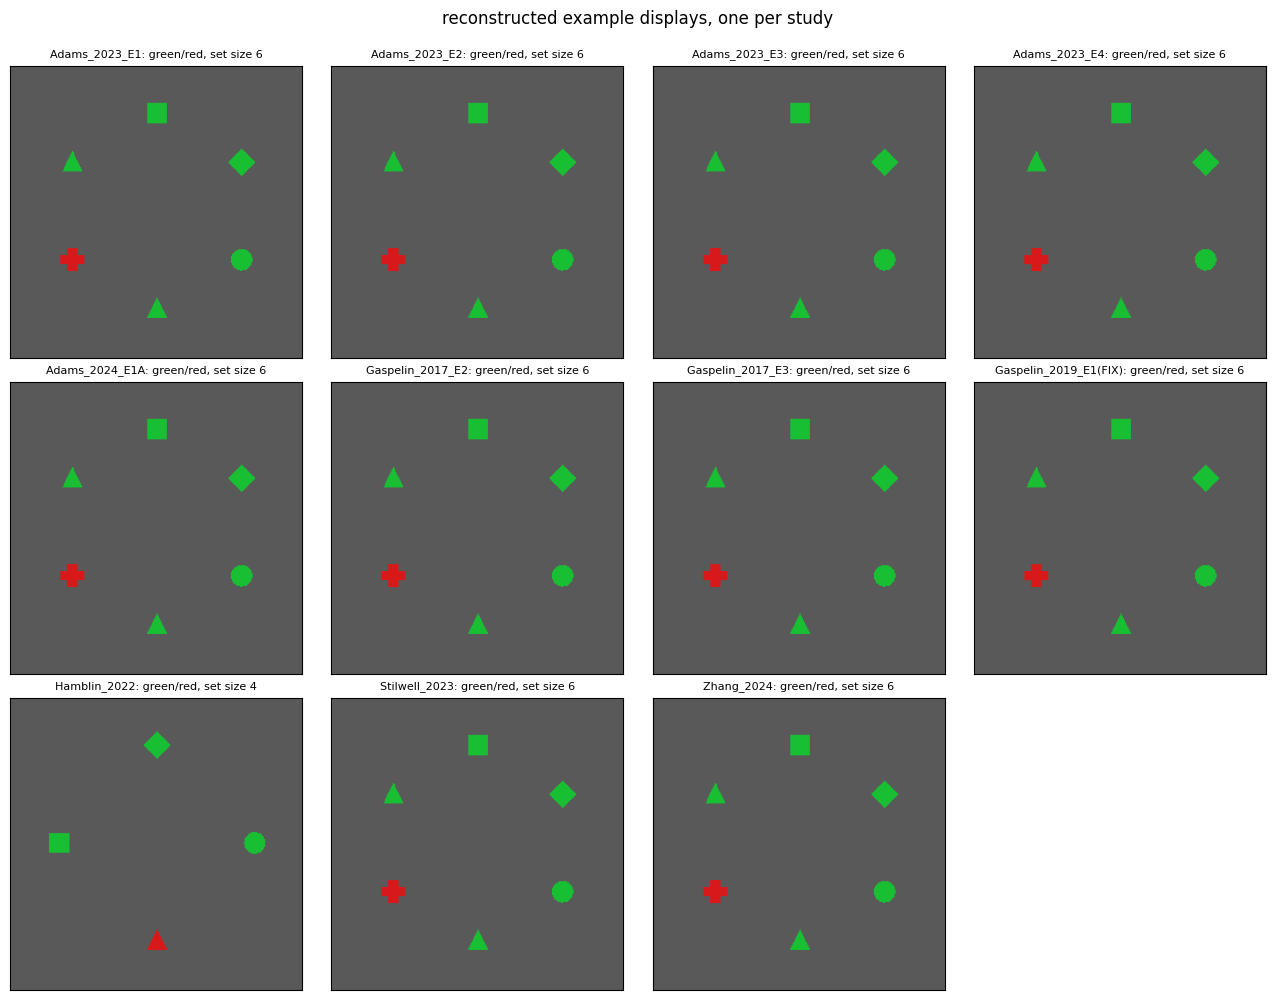

In [3]:
gal = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False,
                  usecols=["study", "setsize", "targCol", "singCol"])
gal = gal[gal.singCol != "none"]

fig, axes = plt.subplots(3, 4, figsize=(13, 10))
for ax, (study, sub) in zip(axes.flat, gal.groupby("study")):
    setsize = int(sub.setsize.mode()[0])
    tc, sc = sub[["targCol", "singCol"]].mode().iloc[0]
    ipos, _ = item_positions(setsize)
    tg, sg = 2, (2 + setsize // 2) % setsize + 1   # target & singleton slots
    items = [dict(x=ipos[j][0], y=ipos[j][1],
                  color=sc if (j + 1) == sg else tc,
                  shape=shape_for(j + 1, tg)) for j in range(setsize)]
    ax.imshow(render(items), origin="lower")
    ax.set_title(f"{study}: {tc}/{sc}, set size {setsize}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])
for ax in axes.flat[gal.study.nunique():]:
    ax.axis("off")
plt.suptitle("reconstructed example displays, one per study", y=0.995)
plt.tight_layout()
plt.show()


## 3. Sensory Evidence

Before the goal can help, the display has to be sensed. The sensory term is goal-independent: it does not know which color or shape is the target. It only says which rendered items are bottom-up color singletons. The background is transparent: it contributes zero sensory evidence.

$$ \text{salience term} = w_S\, S_i $$

For visualization, we paint each item value into its exact footprint as `S(x)`. The fitted model consumes the item value `S_i` directly. The learned weight `w_S` decides whether this bottom-up salience attracts or suppresses first saccades once template evidence and target history are also in play.

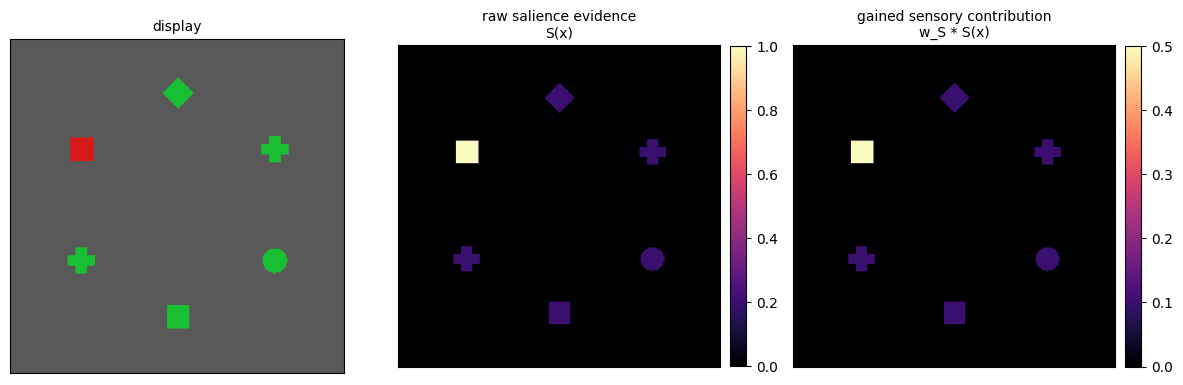

In [4]:

# Canonical display reused through the worked example.
TARG, SING = 1, 4
pos, _ = item_positions(6)
demo_shapes = ["square", "circle", "cross", "diamond", "square", "cross"]
items = [dict(x=pos[j][0], y=pos[j][1],
              color="red" if j == SING else "green",
              shape=demo_shapes[j]) for j in range(6)]
img = render(items)

# Placeholder gain for visualization only; Sec. 8 learns the real value.
wS_demo = 0.5
S_map = sensory_salience_map(items)
sensory_field = wS_demo * S_map

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(img, origin="lower")
axes[0].set_title("display", fontsize=10)

im0 = axes[1].imshow(S_map, origin="lower", cmap="magma", vmin=0, vmax=1)
axes[1].set_title("raw salience evidence\nS(x)", fontsize=10)

im1 = axes[2].imshow(sensory_field, origin="lower", cmap="magma",
                     vmin=0, vmax=max(float(sensory_field.max()), 1e-9))
axes[2].set_title("gained sensory contribution\nw_S * S(x)", fontsize=10)
for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in [(axes[1], im0), (axes[2], im1)]:
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


## 4. Template Evidence

The goal term scales one unified search-template signal:

$$ \text{goal term} = w_G\, G_i $$

`G_i` is signed green-circle template evidence: signed color match and signed shape match are averaged into one item value. A green circle is strongly positive, a red square is strongly negative, and partial matches fall in between. The goal weight does not create this evidence; it only scales evidence already computed from the display.

The weight below is a placeholder; §8 learns the real one. Each panel is scaled to its own range, so compare magnitudes by the color bars.

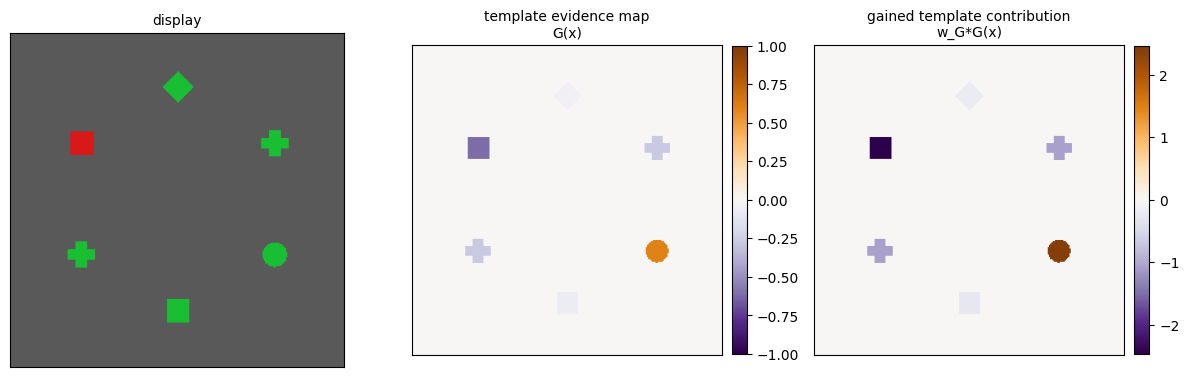

In [5]:
# placeholder goal gain - magnitude picked so the demo map is visible
# (training replaces it with a fitted value)
wG_demo = 4.0

G_map = template_match_map(items, "green")
goal_field = wG_demo * G_map

fig, axes = plt.subplots(1, 3, figsize=(12, 3.8))
axes[0].imshow(img, origin="lower")
axes[0].set_title("display", fontsize=10)

im1 = axes[1].imshow(G_map, origin="lower", cmap="PuOr_r", vmin=-1, vmax=1)
axes[1].set_title("template evidence map\nG(x)", fontsize=10)

v_goal = max(float(np.abs(goal_field).max()), 1e-9)
im2 = axes[2].imshow(goal_field, origin="lower", cmap="PuOr_r",
                     vmin=-v_goal, vmax=v_goal)
axes[2].set_title("gained template contribution\nw_G*G(x)", fontsize=10)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])
for ax, im in [(axes[1], im1), (axes[2], im2)]:
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


In the template evidence map, the target is doubly bright: it has the target color and the target shape. Plain green items carry target-color evidence only, and the red singleton is a signed hole. Orange is positive evidence; purple is negative evidence.

Two features of the shape map worth a second look:

- **The circle is a footprint.** Each item receives one shape-similarity score, and that value is painted across the actual object shape for visualization.
- **Similar shapes still count.** The square, cross, and diamond nontargets receive weaker target-shape evidence according to their circle similarity. Color plays no role: the image is binarized before shape matching.


## 5. Location-based Target History

The model remembers where targets have been. There is one number per item location, updated after every trial as a leaky accumulator:

    H = (1 - eta_H) * H
    H[target location] += eta_H

Each entry is a recency-weighted occupancy between 0 and 1, not a probability; nothing normalizes across locations. `eta_H` is the weight on the newest trial: large `eta_H` means recent trials dominate; small `eta_H` means many past trials average together. `w_H` controls how strongly that learned target-location prior pulls first saccades.

Three panels below:

1. **the accumulator**: `accumulate_history`, replayed over a ten-trial demo history;
2. **the history vector**: one value per item, `w_H*H_i`;
3. **the history map**: that vector painted with the actual item-shape footprints. This map is a display aid; the fitted model uses the item vector directly.


H: [0.   0.71 0.04 0.24 0.   0.01]  (targets, eta_H = 0.6 )
history vector: [0.00e+00 1.43e+00 7.70e-02 4.80e-01 1.00e-03 1.20e-02]


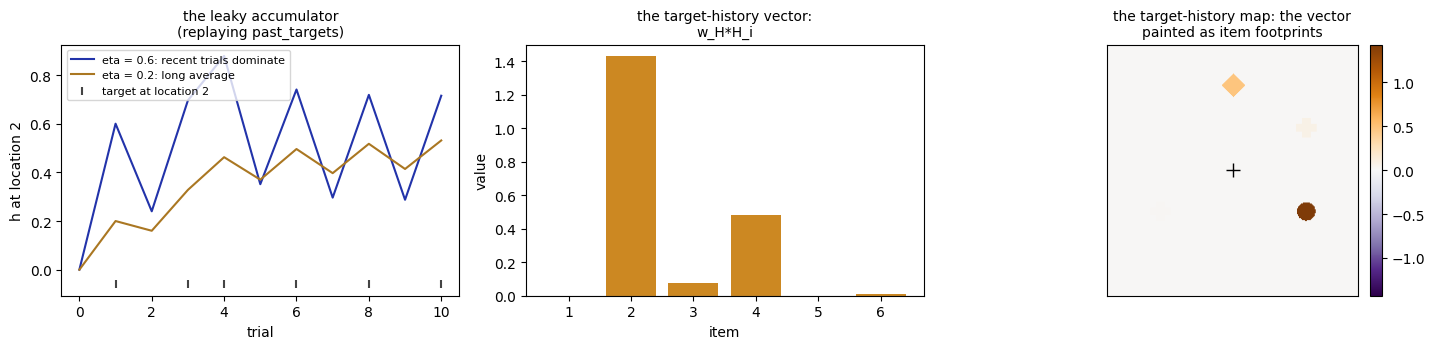

In [6]:
def accumulate_history(past_locs, eta):
    '''The leaky accumulator above, replayed over past trials.
    past_locs: where the item appeared on each previous trial
    (1-6; 0 = absent), oldest first. After each trial everything
    fades by (1 - eta) and that trial's location gets an eta boost.
    (A torch eta makes h a tensor, so Sec. 8's training can take
    gradients through the replay.)'''
    h = torch.zeros(6) if torch.is_tensor(eta) else np.zeros(6)
    for loc in past_locs:
        h = (1 - eta) * h
        if loc:
            h[int(loc) - 1] += eta
    return h

# demo target history, reused all the way to the §7 worked
# example: where the target appeared on the ten previous trials,
# oldest first (1-6 = item location, 0 = absent)
past_targets = [2, 5, 2, 2, 6, 2, 3, 2, 4, 2]   # target favored loc 2
etaH_demo = 0.6                                  # demo memory speed

# replay the SAME target history at two eta values, watch location 2
n_tr = len(past_targets)
h_fast = np.zeros((n_tr + 1, 6)); h_slow = np.zeros((n_tr + 1, 6))
for t in range(n_tr):
    h_fast[t+1] = accumulate_history(past_targets[:t+1], 0.6)
    h_slow[t+1] = accumulate_history(past_targets[:t+1], 0.2)

def selection_history_map(vals, display_items=None):
    # Each patch uses the actual item footprint at that slot, with PEAK
    # HEIGHT 1. A primed square location paints a square, a primed cross
    # location paints a cross, and the target location paints a circle.
    # Torch-ready: with torch vals (Sec. 7) the mask joins them as
    # a tensor so gradients reach w_H and eta_H.
    these_items = items if display_items is None else display_items
    m = paint_history_footprints(these_items, vals)
    return torch.as_tensor(m) if torch.is_tensor(vals) else m

# the memory after those ten trials, built by the same
# accumulate_history the final model reuses in §7
H_demo = accumulate_history(past_targets, etaH_demo)
print("H:", H_demo.round(2), " (targets, eta_H =", etaH_demo, ")")
wH_demo = 2.0      # placeholder gain (near the fitted values)

# ---- the history VECTOR: one number per item location ----
hist_vec = wH_demo*H_demo
print("history vector:", hist_vec.round(3))

# ---- the history MAP: the vector painted with the actual item footprints ----
history_map = selection_history_map(hist_vec, items)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 3.6))
axes[0].plot(h_fast[:, 1], color="#2233aa", label="eta = 0.6: recent trials dominate")
axes[0].plot(h_slow[:, 1], color="#aa7722", label="eta = 0.2: long average")
hit_tr = [t + 1 for t, loc in enumerate(past_targets) if loc == 2]
axes[0].scatter(hit_tr, np.full(len(hit_tr), -0.06),
                marker="|", color="#444444", label="target at location 2")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("h at location 2")
axes[0].set_title("the leaky accumulator\n(replaying past_targets)", fontsize=10)
axes[0].legend(fontsize=8)
cols = ["#cc8822" if v_ >= 0 else "#553388" for v_ in hist_vec]
axes[1].bar(range(1, 7), hist_vec, color=cols)
axes[1].axhline(0, color="#999999", lw=0.8)
axes[1].set_xlabel("item"); axes[1].set_ylabel("value")
axes[1].set_title("the target-history vector:\n"
                  "w_H*H_i", fontsize=10)
v = np.abs(history_map).max()
im_p = axes[2].imshow(history_map, origin="lower", cmap="PuOr_r",
                      vmin=-v, vmax=v)
axes[2].plot(IMG/2, IMG/2, "k+", ms=10)
axes[2].set_title("the target-history map: the vector\npainted as item footprints", fontsize=10)
axes[2].set_xticks([]); axes[2].set_yticks([])
fig.colorbar(im_p, ax=axes[2], fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


## 6. Combining Item Evidence Into Priorities

The fitted model is item-based: sensory evidence (§3), template evidence (§4), and target history (§5) are combined once per candidate item. The 2-D maps in this section are visual displays of those ingredients, not the object optimized by the fitted model.

    F_i = w_S*S_i + w_G*G_i + w_H*H_i


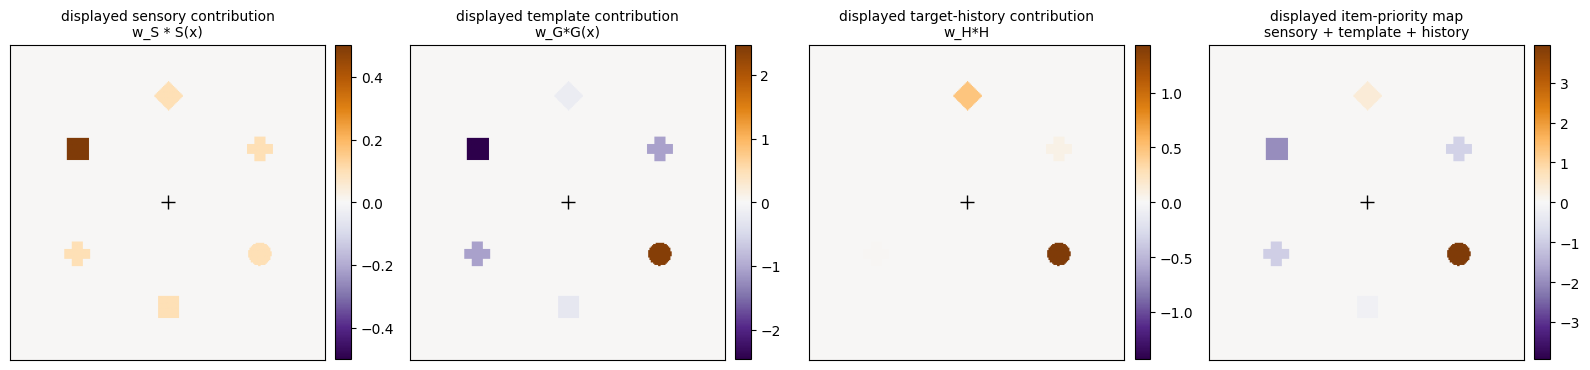

In [7]:

priority_map_demo = sensory_field + goal_field + history_map

fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
plots = [
    (sensory_field, "displayed sensory contribution\nw_S * S(x)"),
    (goal_field, "displayed template contribution\nw_G*G(x)"),
    (history_map, "displayed target-history contribution\nw_H*H"),
    (priority_map_demo, "displayed item-priority map\nsensory + template + history"),
]
for ax, (m, ttl) in zip(axes, plots):
    v = max(np.abs(m).max(), 1e-9)
    im = ax.imshow(m, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
    ax.plot(IMG/2, IMG/2, "k+", ms=10)
    ax.set_title(ttl, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
plt.tight_layout()
plt.show()


## 7. Worked Example: Raw Display to Prediction

The two helper functions below are the tutorial route through the model:

1. **`priority_map`** (§3-6): paint sensory evidence, template evidence, and target history onto the display so we can inspect them;
2. **`predict_saccade`** (§1): read one priority per item and softmax those six values into `P(first saccade)`.

The fitted training loop in §8 skips the pixels and uses the same item values directly. The learned parameters are the four from §1: `w_S`, `w_G`, `w_H`, and `eta_H`.


In [8]:
# accumulate_history and selection_history_map are §5 helpers - reused, not redefined

def priority_map(img, past_targets,
                 w_S, w_G, w_H, eta_H,
                 target_color="green", display_items=None):
    '''Tutorial visualization route from raw display inputs.

    The fitted model is item-based, but this helper paints the same
    sensory evidence, template evidence, and target-history vector into
    display maps so the intermediate fields can be inspected.'''
    pmap = sensory_salience_map(display_items if display_items is not None else items)
    G_map = template_match_map(display_items if display_items is not None else items,
                               target_color)                 # template evidence

    # Fixed maps become tensors here, where they meet learned gains.
    pmap = torch.as_tensor(pmap)
    G_map = torch.as_tensor(G_map)
    sensory_field = w_S * pmap
    goal_field = w_G * G_map

    H = accumulate_history(past_targets, eta_H)        # §5
    history_field = selection_history_map(w_H*H, display_items if display_items is not None else items)
    return sensory_field + goal_field + torch.as_tensor(history_field)


def predict_saccade(pm):
    '''Read one priority per item from the displayed map, then softmax.

    This mirrors the item model for the worked example; §8 uses the
    cached item values directly.'''
    pm = torch.as_tensor(pm)      # keeps gradients when pm carries them
    priorities = []
    for j_ in range(6):
        px_ = int(round((pos[j_][0] + 0.75) / 1.5 * IMG))
        py_ = int(round((pos[j_][1] + 0.75) / 1.5 * IMG))
        priorities.append(pm[py_, px_])
    F_ = torch.stack(priorities).float()[None]
    return torch.softmax(F_, 1), F_

print("the tutorial route: priority_map -> predict_saccade")


the tutorial route: priority_map -> predict_saccade


### One worked example, raw image to prediction

The §3-4 display fields and the §5 histories go in with placeholder
weights; out come the map, the six sensed priorities, and the
prediction. (With these placeholder gains the history bump at
item 2 dominates; §7 learns the real balance.)


priority per item: [-0.26  3.83 -1.    0.3  -2.47 -1.06]
P(first saccade):  [ 1.6 94.   0.8  2.7  0.2  0.7] %
most likely saccade: item 2 (the target; one PREDICTED saccade = one draw from these)


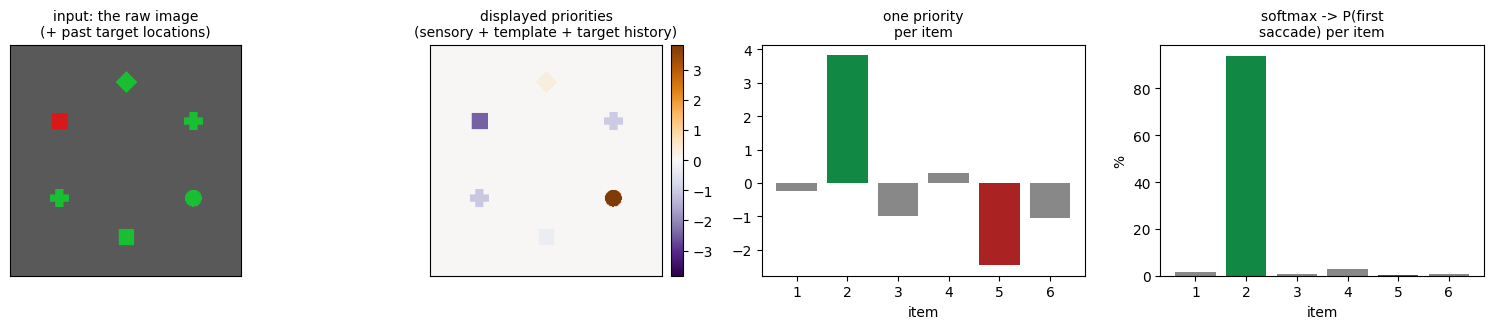

In [9]:
# the four Sec. 1 parameters, in one place
PARAMS = dict(w_S=0.0, w_G=wG_demo,
              w_H=wH_demo, eta_H=etaH_demo)

pm = priority_map(img, past_targets, **PARAMS)
p_ex, F_ex = predict_saccade(pm)

print("priority per item:", F_ex[0].numpy().round(2))
print("P(first saccade): ", (p_ex[0].numpy() * 100).round(1), "%")
print("most likely saccade: item", int(F_ex[0].argmax()) + 1,
      "(the target; one PREDICTED saccade = one draw from these)")

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.4))
axes[0].imshow(img, origin="lower")
axes[0].set_title("input: the raw image\n(+ past target locations)", fontsize=10)
pm_np = np.asarray(pm)
v = np.abs(pm_np).max()
im = axes[1].imshow(pm_np, origin="lower", cmap="PuOr_r", vmin=-v, vmax=v)
axes[1].set_title("displayed priorities\n(sensory + template + target history)", fontsize=10)
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.03)
for ax in axes[:2]:
    ax.set_xticks([]); ax.set_yticks([])
cols = ["#888888"] * 6
cols[TARG], cols[SING] = "#118844", "#aa2222"
axes[2].bar(range(1, 7), F_ex[0].numpy(), color=cols)
axes[2].set_title("one priority\nper item", fontsize=10)
axes[2].set_xlabel("item")
axes[3].bar(range(1, 7), p_ex[0].numpy() * 100, color=cols)
axes[3].set_title("softmax -> P(first\nsaccade) per item", fontsize=10)
axes[3].set_xlabel("item"); axes[3].set_ylabel("%")
plt.tight_layout()
plt.show()


## 8. Train on the actual data

The dataset holds every first saccade from 333 people, plus the full trial order needed to rebuild each person's target-history trace. Excluded at pooling (`pool_data.py`): trials with motion/onset singletons, and Stilwell's low-salience trials. The low-salience trials stay outside fitting and become the counterfactual-style test in §9b.

We hold out 20% of the people and fit by maximum likelihood: replay everyone's trials, score the probability the model gave the real eye movement, and nudge the four parameters by gradient descent.

**Why not call `priority_map()` directly in the loop?** It works as a teaching route, but the fitted model is item-based. Pixel maps would repeatedly repaint the same displays without changing the likelihood. So we cache what the parameters never touch: per display, the three item fields at each candidate item, plus the trial-ordered target-history trace. Each epoch reassembles the six item priorities with the current parameters. Nothing is approximated; the next cell checks the map route against the item cache on one trial.


In [10]:

# build the exact item cache used by the fitted model
import data

sacc = pd.read_csv("dataset/saccades_ctx.csv", low_memory=False)  # a row per first saccade
ev = pd.read_csv("dataset/events.csv", low_memory=False)          # a row per trial
sacc, tt = data.build_tensors(sacc, ev)   # a few minutes: aligns everything
N = len(sacc)

def items_for(setsize, targ, sing, tc="green", sc="red"):
    ipos, _ = item_positions(setsize)
    return [dict(x=ipos[j][0], y=ipos[j][1],
                 color=(sc if j + 1 == sing else tc),
                 shape=shape_for(j + 1, targ)) for j in range(setsize)]

def display_for(setsize, targ, sing, tc="green", sc="red"):
    '''Re-render a display from its trial parameters (Sec. 2/3).'''
    return render(items_for(setsize, targ, sing, tc, sc))

def channel_maps(img_, items_, tc="green"):
    # Model-facing item fields: salience, goal, shape diagnostic.
    pmap = sensory_salience_map(items_)
    G_map = template_match_map(items_, tc)
    s_t = shape_match_map(img_)
    return torch.stack([torch.as_tensor(pmap),
                        torch.as_tensor(G_map),
                        torch.as_tensor(s_t)])

def centers(setsize):
    # display-map readout helper for the §7 sanity check
    ipos, _ = item_positions(setsize)
    return [(int(round((p[1]+0.75)/1.5*IMG)), int(round((p[0]+0.75)/1.5*IMG)))
            for p in ipos]

# every display any saccade saw, sensed: A_CH[display, item, field]
keys = sorted(set(zip(sacc.setsize.astype(int),
                      sacc.targLoc.astype(int), sacc.singLoc.astype(int))))
A_CH = torch.zeros(len(keys), 6, 3)
for d_, key in enumerate(keys):
    items_ = items_for(*key)
    ch = channel_maps(display_for(*key), items_)
    for j_, (py_, px_) in enumerate(centers(key[0])):
        A_CH[d_, j_] = ch[:, py_, px_].float()
# no extra unit step: the fields are greyscale (Sec. 3), so the
# cached values already ARE the model's units
DIDX = {key: i for i, key in enumerate(keys)}
didx = torch.tensor([DIDX[key] for key in
                     zip(sacc.setsize.astype(int), sacc.targLoc.astype(int),
                         sacc.singLoc.astype(int))])

n_subj = tt["eT"].shape[0]
rng = np.random.default_rng(0)
test_subj = torch.zeros(n_subj, dtype=torch.bool)
test_subj[rng.choice(n_subj, n_subj // 5, replace=False)] = True
test = test_subj[tt["si"]]; train = ~test
print(f"{N} saccades, {len(keys)} displays sensed "
      f"({A_CH.numel()} cached numbers); "
      f"{int((~test_subj).sum())} people to train on, "
      f"{int(test_subj.sum())} held out")


114232 saccades, 52 displays sensed (936 cached numbers); 267 people to train on, 66 held out


**Sanity check.** One trial through both routes with the same parameters: the visual `priority_map()` -> `predict_saccade()` route, and the cached item reassembly used for training. The six priorities must agree to float precision.


In [11]:
def cached_F(key, H, w_S, w_G, w_H):
    # reassemble the six item priorities from cached pieces
    s_ = key[0]
    items_ = items_for(*key)
    ch = channel_maps(display_for(*key), items_)
    vals = torch.as_tensor(w_H*H)  # literal target-history model
    F_ = []
    for i_, (py_, px_) in enumerate(centers(s_)):
        stim = w_S*ch[0, py_, px_] + w_G*ch[1, py_, px_]
        F_.append(stim + vals[i_])
    return torch.stack(F_)

pt = past_targets          # the Sec. 5 demo target history
key0 = (6, 1, 4)                      # target slot 1, singleton slot 4
F_lit = predict_saccade(priority_map(display_for(*key0), pt, **PARAMS,
                                      display_items=items_for(*key0)))[1][0]
F_c = cached_F(key0,
               accumulate_history(pt, PARAMS["eta_H"]),
               PARAMS["w_S"], PARAMS["w_G"],
               PARAMS["w_H"])
print("literal:", F_lit.numpy().round(6))
print("cached: ", F_c.float().numpy().round(6))
print(f"max |difference|: {float((F_lit - F_c.float()).abs().max()):.2e}")


literal: [ 2.4       0.35323  -0.107026 -1.987222 -1.599214 -1.064398]
cached:  [ 2.4       0.35323  -0.107026 -1.987222 -1.599214 -1.064398]
max |difference|: 0.00e+00


### The fit, at scale

Per epoch: replay the target memories (because `eta_H` is learning) and reassemble every saccade's six priorities from the cached item values. Set-size-4 displays (Hamblin 2022) use four valid item rows. No unit bookkeeping: the item fields are already in the model's units.


epoch 0: loss 1.5860
epoch 25: loss 1.4661
epoch 50: loss 1.4634
epoch 75: loss 1.4622
epoch 100: loss 1.4618
epoch 125: loss 1.4617
epoch 150: loss 1.4617
epoch 175: loss 1.4617
epoch 200: loss 1.4617
epoch 225: loss 1.4617
epoch 250: loss 1.4617
epoch 275: loss 1.4617


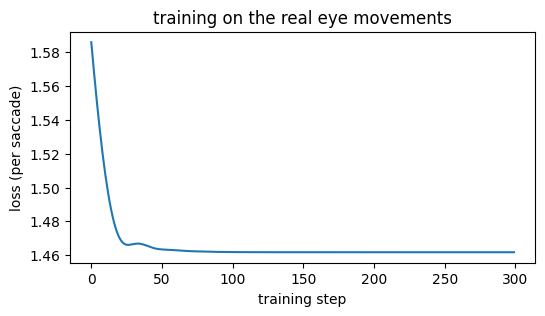

In [12]:
def build_memories(eta_H):
    # replay every subject's trials in order; memory AS OF each trial
    S_, T_, _ = tt["eT"].shape
    H = torch.zeros(S_, 6)
    outT = []
    for t in range(T_):
        outT.append(H)
        H = (1 - eta_H) * H + eta_H * tt["eT"][:, t]
    return torch.stack(outT, 1)

def model_F(w, raw_eta, A_=None):
    """Every saccade's six item priorities: the Sec. 7 model
    reassembled from the item cache. Between epochs only the target
    memories are recomputed; the gains just reweigh cached numbers.
    A_ substitutes alternative item fields for the same trials
    (Sec. 10b's counterfactual displays); default: the real ones."""
    eta_H = torch.sigmoid(raw_eta["H"])
    memT = build_memories(eta_H)
    H = memT[tt["si"], tt["ti"]]
    Ad = (A_CH if A_ is None else A_)[didx]        # item fields: salience, goal, shape diagnostic
    w_G = torch.nn.functional.softplus(w["raw_w_G"])
    stimulus = w["w_S"]*Ad[..., 0] + w_G*Ad[..., 1]
    F = stimulus + w["w_H"] * H
    return F, memT

w = {name: torch.tensor(v, requires_grad=True) for name, v in
     [("w_S", 0.0), ("raw_w_G", 0.0),
      ("w_H", 0.5)]}
raw_eta = {"H": torch.tensor(0.0, requires_grad=True)}
optimizer = torch.optim.Adam(list(w.values()) + list(raw_eta.values()), lr=0.05)

losses = []
for epoch in range(300):
    F, _ = model_F(w, raw_eta)
    F = F.masked_fill(~tt["valid"], -1e9)
    logp = torch.log_softmax(F, 1).gather(
        1, tt["choice"][:, None]).squeeze(1)
    loss = -logp[train].mean()
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())
    if epoch % 25 == 0:
        print(f"epoch {epoch}: loss {loss.item():.4f}", flush=True)

plt.figure(figsize=(6, 3))
plt.plot(losses)
plt.xlabel("training step"); plt.ylabel("loss (per saccade)")
plt.title("training on the real eye movements")
plt.show()


In [13]:
learned = {k: v.item() for k, v in w.items() if k != "raw_w_G"}
learned["w_G"] = torch.nn.functional.softplus(w["raw_w_G"]).item()
learned["eta_H"] = torch.sigmoid(raw_eta["H"]).item()

for name, meaning in [
        ("w_S", "bottom-up sensory color salience"),
        ("w_G", "modulates green-circle template match"),
        ("w_H", "pull toward past target locations"),
        ("eta_H", "weight on recent target locations")]:
    print(f"{name:8} = {learned[name]:+7.3f}   {meaning}")


w_S      =  -0.050   bottom-up sensory color salience
w_G      =  +1.339   modulates green-circle template match
w_H      =  +2.092   pull toward past target locations
eta_H    =  +0.588   weight on recent target locations


## 9. Evaluation: held-out log-likelihood against human consistency

We score the model on people it never saw, by the log-likelihood it
assigns to their actual first saccades. For each held-out saccade the
model places a probability on the item the eyes reached; the mean
negative log of that probability, in nats per saccade, is the loss.
Lower is better, and log-likelihood rewards the model for putting
probability where behavior actually goes rather than for any single
guess.

A raw log-likelihood means little on its own, so we compare it to a
baseline built from the people themselves: a human-consistency table.
Every display falls into a context, a unique configuration of set size,
target location, singleton location, and colors (the `ctx` id from
`build_contexts`). For each context we take the TRAINING people's first
saccades and record the fraction that went to each item. That fraction
is the prediction for a held-out person who sees the same display: how
well the rest of the crowd predicts this person. Note that it knows the
display perfectly but has no access to the person's own trial-by-trial
history, so the gap between it and the model isolates what the
target-history trace contributes.

We test the difference at the level of the held-out person, the same
unit as the analyses below: each person's mean log-likelihood under the
model and under human consistency, compared with a paired t-test and
Cohen's d across the held-out people.

In [14]:
import pingouin as pg

# model: held-out log-likelihood of the actual first saccades
with torch.no_grad():
    F, memT = model_F(w, raw_eta)
    F = F.masked_fill(~tt["valid"], -1e9)
    prob = torch.softmax(F, 1)
    lp_model = torch.log_softmax(F, 1).gather(
        1, tt["choice"][:, None]).squeeze(1)   # log p(fixated item), per saccade

# human consistency: the fraction of TRAINING people's first saccades
# that went to each item on this display context (the `ctx` id). No
# smoothing - every held-out choice was also made by some training
# person on the same display, so the empirical fraction is nonzero.
ctx = torch.as_tensor(pd.factorize(sacc["ctx"].values)[0])
counts = torch.zeros(int(ctx.max()) + 1, 6)
counts.index_put_((ctx[train], tt["choice"][train]),
                  torch.ones(int(train.sum())), accumulate=True)
tab = counts[ctx]
lp_human = (tab.gather(1, tt["choice"][:, None]).squeeze(1) / tab.sum(1)).log()

for name, lp in [("model", lp_model), ("human consistency", lp_human)]:
    print(f"held-out NLL, {name:17}: {-lp[test].mean():.4f} nats/saccade")

# test at the level of the held-out person (the unit used in 9a-c):
# each person's mean log-likelihood under the two models, paired.
si = tt["si"]
sub = torch.unique(si[test])
m = torch.stack([lp_model[test & (si == s)].mean() for s in sub])
h = torch.stack([lp_human[test & (si == s)].mean() for s in sub])
res = pg.ttest(m.numpy(), h.numpy(), paired=True)
diff = (m - h).numpy()
gain_bits = diff / np.log(2)               # information gain per saccade, per person
cohen_d = res["cohen_d"].iloc[0]           # pooled Cohen's d (matches 9a)

p_val = res["p_val"].iloc[0]
print(f"\nmodel over human consistency: {gain_bits.mean():.3f} bits/saccade, "
      f"model wins for {int((m > h).sum())}/{len(sub)} held-out people")
print(f"paired t({int(res['dof'].iloc[0])}) = {res['T'].iloc[0]:.2f}, "
      f"{'p < .001' if p_val < .001 else f'p = {p_val:.3f}'}, "
      f"Cohen's d = {cohen_d:.2f}")

held-out NLL, model            : 1.4036 nats/saccade
held-out NLL, human consistency: 1.5437 nats/saccade

model over human consistency: 0.178 bits/saccade, model wins for 53/66 held-out people
paired t(65) = 6.72, p < .001, Cohen's d = 0.62


**Interpretation.** The model assigns held-out people's first saccades
a higher log-likelihood than the human-consistency baseline does, and
the advantage holds for most held-out people one by one, not only on
average. Because the baseline already knows the display, the margin is
attributable to the between-trial target history, which the model
carries and a display-indexed table cannot represent. Reported in bits,
the gain is the extra information per saccade the history trace buys
over knowing the display and the crowd.

Two cautions. Human consistency is a floor here, not a ceiling: the
model beats it, so it does not bound how well any model could do, and
the true ceiling (the conditional entropy of behavior) is not fixed by
any table. And the comparison is only clean when both models are scored
on the identical held-out split.

### 9a. Oculomotor suppression

Held-out people only; nothing below was fitted to these patterns —
they fall out of the one trained equation. First saccades go to the
salient red singleton LESS often than to an average plain item — the
below-baseline suppression this dataset exists to measure.


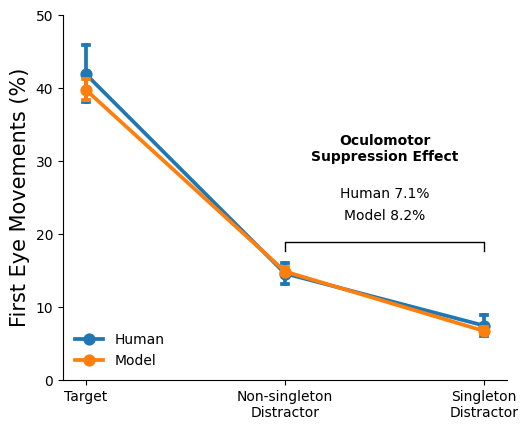

Human: non-singleton vs singleton distractor (paired across 66 held-out subjects)
      T  dof alternative  p_val         CI95  cohen_d  power      BF10
10.7883   65   two-sided    0.0 [5.82, 8.47]   1.2096    1.0 1.599e+13 

Model: non-singleton vs singleton distractor (paired across 66 held-out subjects)
     T  dof alternative  p_val         CI95  cohen_d  power      BF10
23.352   65   two-sided    0.0 [7.46, 8.86]    3.676    1.0 1.009e+30 



In [15]:
first = torch.tensor((sacc.saccindex == 1).values)  # all True: the scope
sing_present = torch.tensor((sacc.singLoc > 0).values)
rows = torch.arange(N)
isT = torch.zeros(N, 6); isT[rows, torch.tensor(sacc.targLoc.values) - 1] = 1
isS = torch.zeros(N, 6)
sp = torch.tensor(sacc.singLoc.values)
isS[rows[sp > 0], sp[sp > 0] - 1] = 1
chose = torch.zeros(N, 6); chose[rows, tt["choice"]] = 1

m = test & first & sing_present

# REGENERATE the test saccades: one model saccade per real trial,
# drawn from the predicted probabilities (each trial conditioned on
# the subject's actual history). The model line then carries the
# same trial-count binomial noise as the people line, so its error
# bars and t-test are commensurable with the data's.
gen = torch.Generator().manual_seed(0)
sim = torch.multinomial(prob[m], 1, generator=gen).squeeze(1)
simch = torch.zeros(int(m.sum()), 6)
simch[torch.arange(int(m.sum())), sim] = 1

def subject_rates(ch_):
    """One set of saccades (0/1 choice rows over mask m) -> each
    held-out subject's landing rates (%): columns t (target),
    ns (plain-item average), s (singleton)."""
    d_ = pd.DataFrame(dict(
        si=tt["si"][m].numpy(),
        t=(ch_ * isT[m]).sum(1).numpy(),
        s=(ch_ * isS[m]).sum(1).numpy(),
        n_pl=(tt["valid"][m].sum(1).float() - 2).clamp(min=1).numpy()))
    d_["ns"] = (1 - d_.t - d_.s) / d_.n_pl
    return d_.drop(columns="n_pl").groupby("si").mean() * 100

def rates_long(frames_, cond_name):
    """{condition: subject_rates frame} -> long form for seaborn:
    one row per subject x condition x item type."""
    cat = pd.concat([fr[["t", "ns", "s"]].reset_index().assign(**{cond_name: k})
                     for k, fr in frames_.items()])
    return cat.melt(id_vars=["si", cond_name], var_name="item",
                    value_name="rate")

frames = {"Human": subject_rates(chose[m]), "Model": subject_rates(simch)}

# the suppression effect (non-singleton minus singleton), tested
# separately per line: paired t-test across subjects
import pingouin as pg
tests = {src_: pg.ttest(fr["ns"], fr["s"], paired=True)
         for src_, fr in frames.items()}

def p_str(t_):
    p = t_["p_val"].iloc[0]
    return "p < .001" if p < .001 else f"p = {p:.3f}"

# seaborn does the means and the bootstrapped 95% CIs (over the
# subject-level rows) itself
import seaborn as sns
fig9a, ax = plt.subplots(figsize=(5.4, 4.4))
ax = sns.pointplot(data=rates_long(frames, "source"), x="item", y="rate",
                   hue="source", order=["t", "ns", "s"],
                   hue_order=["Human", "Model"],
                   errorbar=("ci", 95), n_boot=10000, seed=0, capsize=0.03)
supp = {src_: fr["ns"].mean() - fr["s"].mean() for src_, fr in frames.items()}
top = max(fr["ns"].mean() for fr in frames.values()) + 4
ax.plot([1, 1, 2, 2], [top - 1.2, top, top, top - 1.2], "k-", lw=1)
ax.text(1.5, 30, "Oculomotor\nSuppression Effect", ha="center", fontsize=10, fontweight="bold")
ax.text(1.5, 25, f"Human {supp['Human']:.1f}%", ha="center", fontsize=10)
ax.text(1.5, 22, f"Model {supp['Model']:.1f}%", ha="center", fontsize=10)
ax.set_xticks([0, 1, 2], ["Target", "Non-singleton\nDistractor", "Singleton\nDistractor"])
ax.set_xlabel(""); ax.set_ylabel("First Eye Movements (%)", fontsize=15)
ax.set_ylim(0, 50)
ax.legend(loc="lower left", frameon=False, title=None, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for src_ in ("Human", "Model"):
    print(f"{src_}: non-singleton vs singleton distractor "
          f"(paired across {len(frames[src_])} held-out subjects)")
    print(tests[src_].round(4).to_string(index=False), "\n")


### 9b. High- vs low-salience suppression (Stilwell)
Stilwell (2023) found MORE suppression for MORE salient singletons. A
strong test: the low-salience trials were excluded from our data
entirely (§8) — the model has never seen them. We apply the
trained weights, unchanged, to displays rendered in the pipeline's
schematic colors (a red vs a less-red family; the claim is the
qualitative gradient, not Stilwell's exact colors or numbers).

(Design: the real held-out trials ARE the high-salience
condition — green target, red singleton. We run one counterfactual
second pass over the SAME trials with the singleton re-rendered in
teal (near the target color = low salience), keeping each
subject's real selection history, and regenerate saccades from
both passes. One line per condition, all three item types; the
suppression difference is the salience x item-type interaction in
a repeated-measures ANOVA over the held-out subjects. For
reference, people show the same gradient: 7.0% vs 11.3% first
saccades to the singleton — from the full battery over all of
Stilwell's color pairs, the raw low-salience files are
not in the repo.)


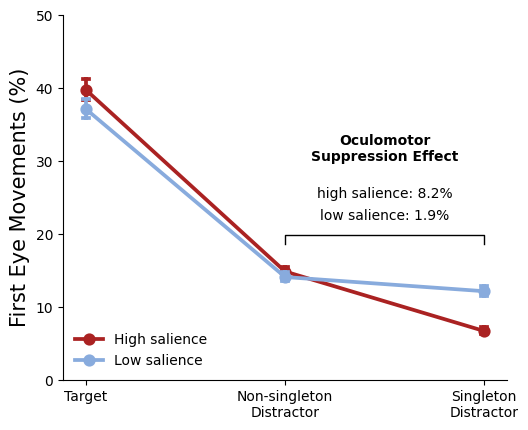

singleton landing rate, high vs low salience (paired across 66 held-out subjects): 6.7% vs 12.2%
       T  dof alternative  p_val           CI95  cohen_d  power      BF10
-15.0715   65   two-sided    0.0 [-6.18, -4.74]   2.3062    1.0 6.214e+19


In [16]:
# The REAL held-out trials are the HIGH-salience condition: every
# display is a green target with a RED singleton (opposite color).
# Counterfactual second pass, Han's design: re-sense the SAME
# trials with a TEAL singleton (near the target color = LOW
# salience), keep each subject's real selection history, and
# regenerate saccades for both passes. High pass: 9a's simulated
# saccades; low pass: drawn below.
A_LOW = torch.zeros_like(A_CH)
for d_, key in enumerate(keys):
    items_ = items_for(*key, sc="teal")
    ch = channel_maps(display_for(*key, sc="teal"), items_)
    for j_, (py_, px_) in enumerate(centers(key[0])):
        A_LOW[d_, j_] = ch[:, py_, px_].float()

with torch.no_grad():
    F_low, _ = model_F(w, raw_eta, A_LOW)
prob_low = torch.softmax(F_low.masked_fill(~tt["valid"], -1e9), 1)
gen3 = torch.Generator().manual_seed(2)
sim_low = torch.multinomial(prob_low[m], 1, generator=gen3).squeeze(1)
simch_low = torch.zeros(int(m.sum()), 6)
simch_low[torch.arange(int(m.sum())), sim_low] = 1

# the high pass IS 9a: same saccades, same per-subject frame -
# only the low pass is new
passes = {"High salience": frames["Model"],
          "Low salience": subject_rates(simch_low)}
long9b = rates_long(passes, "salience")

# Stilwell prediction: a more salient singleton is suppressed more, so it
# is fixated LESS often. Test the singleton landing rate directly: high
# vs low salience, paired across the held-out subjects.
res9b = pg.ttest(passes["High salience"]["s"], passes["Low salience"]["s"],
                 paired=True)

fig9b, ax = plt.subplots(figsize=(5.4, 4.4))
ax = sns.pointplot(data=long9b, x="item", y="rate", hue="salience",
                   order=["t", "ns", "s"], hue_order=list(passes),
                   palette={"High salience": "#aa2222", "Low salience": "#88abdd"},
                   errorbar=("ci", 95), n_boot=10000, seed=0, capsize=0.03)
supp_ = {sal: p_["ns"].mean() - p_["s"].mean() for sal, p_ in passes.items()}
top = max(p_["ns"].mean() for p_ in passes.values()) + 5
ax.plot([1, 1, 2, 2], [top - 1.2, top, top, top - 1.2], "k-", lw=1)
ax.text(1.5, 30, "Oculomotor\nSuppression Effect", ha="center", fontsize=10, fontweight="bold")
ax.text(1.5, 25, f"high salience: {supp_['High salience']:.1f}%", ha="center", fontsize=10)
ax.text(1.5, 22, f"low salience: {supp_['Low salience']:.1f}%", ha="center", fontsize=10)
ax.set_xticks([0, 1, 2], ["Target", "Non-singleton\nDistractor", "Singleton\nDistractor"])
ax.set_xlabel(""); ax.set_ylabel("First Eye Movements (%)", fontsize=15)
ax.set_ylim(0, 50)
ax.legend(loc="lower left", frameon=False, title=None, fontsize=10)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"singleton landing rate, high vs low salience "
      f"(paired across {long9b.si.nunique()} held-out subjects): "
      f"{passes['High salience']['s'].mean():.1f}% vs "
      f"{passes['Low salience']['s'].mean():.1f}%")
print(res9b.round(4).to_string(index=False))

In [17]:
# subject-level means
long9b.groupby(["salience", "item"]).mean().reset_index()

,salience,item,si,rate
0,High salience,ns,161.378788,14.888398
1,High salience,s,161.378788,6.727696
2,High salience,t,161.378788,39.780075
3,Low salience,ns,161.378788,14.132253
4,Low salience,s,161.378788,12.188456
5,Low salience,t,161.378788,37.148754


The mechanism: `G` combines color and shape match in one signed
template map. A low-salience singleton carries weaker color mismatch;
a high-salience singleton carries stronger negative color evidence.
If it also has the wrong shape, the shape term makes it more negative
than a same-color circle. The learned `w_G` is constrained positive,
so this sign structure cannot flip during training.

### 9c. Target location priming

Saccades to the target roughly double when the target repeats its
location — the selection-history machinery at work. We compare first
saccades to the target on trials where its location REPEATED versus
CHANGED from the previous trial, for held-out people and for the
model's regenerated saccades; the bracket gives the repeat − change
effect, its paired-t p, and Cohen's d.

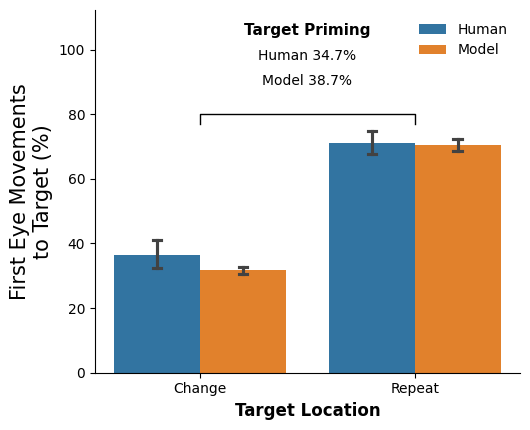

Human, target location: repeat vs change (paired across 66 held-out subjects)
    T  dof alternative  p_val           CI95  cohen_d  power      BF10
18.55   65   two-sided    0.0 [30.99, 38.47]   2.1078    1.0 2.865e+24 

Model, target location: repeat vs change (paired across 66 held-out subjects)
      T  dof alternative  p_val           CI95  cohen_d  power      BF10
45.8595   65   two-sided    0.0 [36.99, 40.36]   6.3089    1.0 4.008e+47 



In [18]:
ev2 = ev.copy()
ev2["block"] = pd.to_numeric(ev2["block"], errors="coerce").fillna(0.0)
ev2["trial"] = pd.to_numeric(ev2["trial"], errors="coerce")
ev2["subj"] = ev2["subj"].astype(str)
ev2 = ev2.sort_values(["study", "subj", "block", "trial"])
ev2["prevT"] = ev2.groupby(["study", "subj"]).targLoc.shift(1)
key = ["study", "subj", "block", "trial"]
sacc2 = sacc.merge(ev2[key + ["prevT"]], on=key, how="left")

# regenerated saccades for ALL trials (9a's logic, whole dataset):
# one draw per real trial from the predicted probabilities
gen2 = torch.Generator().manual_seed(1)
sim2 = torch.multinomial(prob, 1, generator=gen2).squeeze(1)
simch2 = torch.zeros(N, 6); simch2[torch.arange(N), sim2] = 1

def priming_panel(ax, m_change, m_repeat, pick, effect_name, what):
    """Change vs Repeat bars (Human +
    model from the regenerated saccades), per-subject means over
    held-out subjects; seaborn computes the bootstrapped 95% CIs.
    Bracket: effect (repeat - change), p, and Cohen's d from a paired
    t-test across subjects."""
    fr_ = {}
    for cond, m_ in (("Change", m_change), ("Repeat", m_repeat)):
        d_ = pd.DataFrame(dict(
            si=tt["si"][m_].numpy(),
            Human=(chose[m_] * pick[m_]).sum(1).numpy(),
            Model=(simch2[m_] * pick[m_]).sum(1).numpy()))
        fr_[cond] = d_.groupby("si").mean() * 100
    both = fr_["Change"].join(fr_["Repeat"], lsuffix="_ch",
                              rsuffix="_rep").dropna()
    tests_ = {src_: pg.ttest(both[src_ + "_rep"], both[src_ + "_ch"],
                             paired=True) for src_ in ("Human", "Model")}
    long_ = pd.concat([fr.loc[both.index].reset_index().assign(cond=cond)
                       for cond, fr in fr_.items()])
    long_ = long_.melt(id_vars=["si", "cond"], var_name="source",
                       value_name="rate")
    sns.barplot(data=long_, x="cond", y="rate", hue="source",
                order=["Change", "Repeat"],
                hue_order=["Human", "Model"],
                #palette={"Human": "#444444", "Model": "#2233aa"},
                errorbar=("ci", 95), n_boot=10000, seed=0,
                capsize=0.08, ax=ax)
    top = long_.groupby(["cond", "source"]).rate.mean().max() * 1.08
    ax.plot([0, 0, 1, 1], [top, top * 1.04, top * 1.04, top],
            "k-", lw=1)
    ax.text(0.5, top * 1.36, effect_name, ha="center", fontsize=11,
            fontweight="bold")
    for k, src_ in enumerate(['Human','Model']):
        t_ = tests_[src_]
        eff = both[src_ + "_rep"].mean() - both[src_ + "_ch"].mean()
        d = t_["cohen_d"].iloc[0]           # pooled Cohen's d (matches 9/9a)
        ax.text(0.5, top * (1.26 - 0.10 * k),
                f"{src_} {eff:.1f}%",
                ha="center", fontsize=10)
    ax.set_xlabel(what, fontsize=12, fontweight="bold")
    ax.set_ylabel(f"First Eye Movements\nto {what.split()[0]} (%)", fontsize=15)
    ax.set_ylim(0, top * 1.46)
    return tests_, len(both)

fig9c, ax = plt.subplots(figsize=(5.4, 4.4))
tr = test & first & torch.tensor(sacc2.prevT.values == sacc.targLoc.values)
tc_ = test & first & torch.tensor((sacc2.prevT.values != sacc.targLoc.values)
                                  & ~np.isnan(sacc2.prevT.values))
tests_T, nT = priming_panel(ax, tc_, tr, isT, "Target Priming",
                            "Target Location")
ax.legend(loc="best", frameon=False, title=None)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

for src_ in ("Human", "Model"):
    print(f"{src_}, target location: repeat vs change "
          f"(paired across {nT} held-out subjects)")
    print(tests_T[src_].round(4).to_string(index=False), "\n")

### 9d. Combined Evaluation Figure

This cell redraws the three §9 results into one figure for presentation.


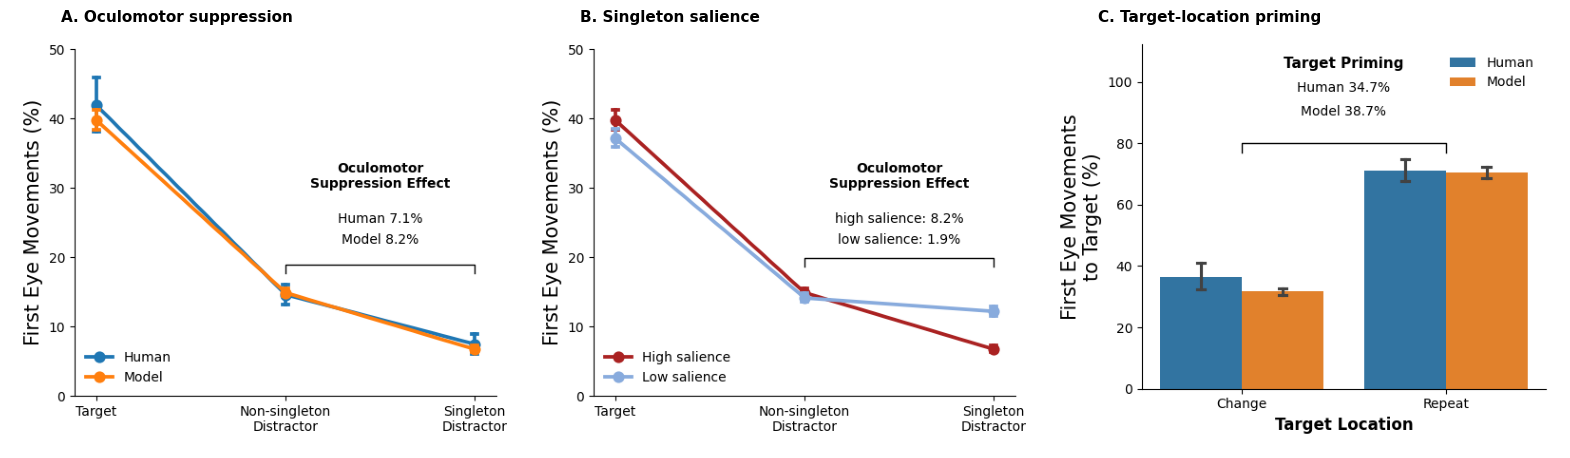

In [19]:
def figure_image(fig):
    fig.canvas.draw()
    return np.asarray(fig.canvas.buffer_rgba())

fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.6))
for ax, panel, title, src_fig in zip(
        axes,
        ["A", "B", "C"],
        ["Oculomotor suppression", "Singleton salience", "Target-location priming"],
        [fig9a, fig9b, fig9c]):
    ax.imshow(figure_image(src_fig))
    ax.set_axis_off()
    ax.text(0.1, 1.05, f"{panel}. {title}", transform=ax.transAxes,
            ha="left", va="top", fontsize=11, fontweight="bold")
plt.tight_layout(w_pad=0.4)
plt.show()
